# Federal Incentive Solar Adoption Simulation

This notebook runs the ZIP-level solar adoption simulator for a single federal incentive scenario.

Update the parameters in the next cell, then run all cells.

In [25]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Find repository root from this notebook location.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "Models").exists():
    repo_root = repo_root.parent

if not (repo_root / "Models").exists():
    raise RuntimeError("Could not locate repository root containing 'Models' directory.")

# Import incentives modules in the working directory they expect for relative data paths.
models_incentives_dir = repo_root / "Models" / "Incentives"
if str(models_incentives_dir) not in sys.path:
    sys.path.insert(0, str(models_incentives_dir))

original_cwd = Path.cwd()
os.chdir(models_incentives_dir)
import simulated_decision as sd
os.chdir(original_cwd)

plt.style.use("seaborn-v0_8")

In [26]:
# --- Simulation parameters ---
STATE_CODE = "CA"
FEDERAL_INCENTIVE_DOLLARS = 2000  # positive dollar amount
YEARS_TO_SIMULATE = 5
MAX_ZIPCODES = 40  # reduce for faster runs
SOLAR_SYSTEM_KW = 7
BASE_INSTALLATION_COST = 17500
RANDOM_SEED = 42

# Payback-threshold evolution logic:
# - "data_calibrated": calibrate yearly cutoffs to adoption targets from state_behavior.csv (recommended)
# - "legacy_exponential": original code path
# - "annualized_horizon": treat CSV growth as a horizon multiplier
# - "linear_horizon": linear interpolation to horizon multiplier
GROWTH_LOGIC = "data_calibrated"
COMPARE_GROWTH_LOGICS = True

# Target adoption semantics:
# - "absolute_total": target includes already-adopted baseline
# - "additional_only": target is new adoption only (starts from annual increment)
TARGET_ADOPTION_MODE = "additional_only"

# Cache controls (under Examples/model_cache)
USE_MODEL_CACHE = True
FORCE_REBUILD_CACHE = False
np.random.seed(RANDOM_SEED)

# Internal sign convention in the model: incentives are negative values.
model_incentive = -abs(FEDERAL_INCENTIVE_DOLLARS)

zips_df = pd.read_csv(repo_root / "Data" / "Clean_Data" / "zips.csv")
state_behavior_df = pd.read_csv(repo_root / "Models" / "Incentives" / "state_behavior.csv")

state_row = state_behavior_df[state_behavior_df["State code"] == STATE_CODE]
if state_row.empty:
    raise ValueError(f"State code '{STATE_CODE}' not found in state_behavior.csv")

state_row = state_row.iloc[0]
state_incentive = float(state_row["Numeric state-level upfront incentive"])
payback_cutoff = float(state_row["payback_period_first_year_cutoff"])
raw_growth_rate = float(state_row["year_over_year_growth"])
status_quo_adoption = float(state_row["prop_adopted_status_quo"][1:-1])
yearly_adoption_increment = float(state_row["prop_adopted_per_year_average"])

if YEARS_TO_SIMULATE < 2:
    raise ValueError("YEARS_TO_SIMULATE must be >= 2 for growth logic.")

def build_target_adoption_curve(base_adoption, annual_increment, years_total, mode):
    targets = []
    for year in range(1, years_total + 1):
        if mode == "absolute_total":
            target = base_adoption + year * annual_increment
        elif mode == "additional_only":
            target = year * annual_increment
        else:
            raise ValueError(f"Unknown TARGET_ADOPTION_MODE: {mode}")

        targets.append(float(np.clip(target, 0.0, 1.0)))
    return targets

def year_cutoff_value(year_idx, first_year_cutoff, raw_growth, years_total, logic):
    if logic == "legacy_exponential":
        return first_year_cutoff * (raw_growth ** year_idx)

    if logic == "annualized_horizon":
        annual_growth = raw_growth ** (1 / (years_total - 1))
        return first_year_cutoff * (annual_growth ** year_idx)

    if logic == "linear_horizon":
        horizon_multiplier = 1 + (raw_growth - 1) * (year_idx / (years_total - 1))
        return first_year_cutoff * horizon_multiplier

    raise ValueError(f"Unknown GROWTH_LOGIC: {logic}")

state_zipcodes = zips_df.loc[zips_df["state_code"] == STATE_CODE, "zip"].astype(int).tolist()
selected_zipcodes = state_zipcodes[:MAX_ZIPCODES] if MAX_ZIPCODES else state_zipcodes
target_adoption_curve = build_target_adoption_curve(
    status_quo_adoption,
    yearly_adoption_increment,
    YEARS_TO_SIMULATE,
    TARGET_ADOPTION_MODE,
)

print(f"State: {STATE_CODE}")
print(f"ZIP codes selected: {len(selected_zipcodes)} / {len(state_zipcodes)}")
print(f"Federal incentive tested: ${FEDERAL_INCENTIVE_DOLLARS:,.0f}")
print(f"Model incentive value: {model_incentive}")
print(f"State upfront incentive: ${state_incentive:,.0f}")
print(f"Raw growth value from CSV: {raw_growth_rate:.3f}")
print(f"Status-quo adoption (data): {status_quo_adoption:.4f}")
print(f"Annual adoption increment (data): {yearly_adoption_increment:.4f}")
print(f"Target adoption mode: {TARGET_ADOPTION_MODE}")
print(f"Active growth logic: {GROWTH_LOGIC}")

cutoff_preview = pd.DataFrame(
    {
        "year": list(range(1, YEARS_TO_SIMULATE + 1)),
        "target_adoption_from_data": target_adoption_curve,
        "status_quo_baseline": [status_quo_adoption] * YEARS_TO_SIMULATE,
        "legacy_exponential": [
            year_cutoff_value(i, payback_cutoff, raw_growth_rate, YEARS_TO_SIMULATE, "legacy_exponential")
            for i in range(YEARS_TO_SIMULATE)
        ],
        "annualized_horizon": [
            year_cutoff_value(i, payback_cutoff, raw_growth_rate, YEARS_TO_SIMULATE, "annualized_horizon")
            for i in range(YEARS_TO_SIMULATE)
        ],
        "linear_horizon": [
            year_cutoff_value(i, payback_cutoff, raw_growth_rate, YEARS_TO_SIMULATE, "linear_horizon")
            for i in range(YEARS_TO_SIMULATE)
        ],
    }
)
display(cutoff_preview)

State: CA
ZIP codes selected: 40 / 1096
Federal incentive tested: $2,000
Model incentive value: -2000
State upfront incentive: $0
Raw growth value from CSV: 2.250
Status-quo adoption (data): 0.1162
Annual adoption increment (data): 0.0121
Target adoption mode: additional_only
Active growth logic: data_calibrated


,year,target_adoption_from_data,status_quo_baseline,legacy_exponential,annualized_horizon,linear_horizon
0,1,0.012094,0.116244,1.974407,1.974407,1.974407
1,2,0.024189,0.116244,4.442416,2.418145,2.591410
2,3,0.036283,0.116244,9.995437,2.961611,3.208412
3,4,0.048378,0.116244,22.489733,3.627218,3.825414
4,5,0.060472,0.116244,50.601898,4.442416,4.442416


In [27]:
import pickle


def build_cache_path():
    cache_dir = repo_root / "Examples" / "model_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir / (
        f"zip_payloads_{STATE_CODE}_n{len(selected_zipcodes)}_"
        f"cost{int(BASE_INSTALLATION_COST-state_incentive)}_kw{SOLAR_SYSTEM_KW}.pkl"
    )


def build_zip_payloads_for_selected_zipcodes():
    payloads = []
    failed_zipcodes = []

    for zip_code in tqdm(selected_zipcodes, desc="Building ZIP models", unit="zip"):
        try:
            model = sd.SolarAdoptionModelZipCode(zip_code)
            installation_cost = BASE_INSTALLATION_COST - state_incentive
            model.set_installation_cost(installation_cost)
            model.set_solar_offset_per_home(solar_pv_sizing_kw=SOLAR_SYSTEM_KW)
            model.generate_agents()

            if len(model.schedule.agents) == 0:
                failed_zipcodes.append(zip_code)
                continue

            # Precompute per-agent yearly savings coefficient so repeated runs are fast.
            yearly_savings_coeff = []
            for agent in model.schedule.agents:
                burden = model.get_energy_burden_from_income(agent.income)
                ratio = model.get_energy_ratio_from_income(agent.income)
                yearly_savings_coeff.append(float(burden * agent.income * ratio))

            payloads.append(
                {
                    "zip": int(zip_code),
                    "num_agents": len(model.schedule.agents),
                    "installation_cost": float(installation_cost),
                    "yearly_savings_coeff": np.array(yearly_savings_coeff, dtype=float),
                }
            )
        except Exception:
            failed_zipcodes.append(zip_code)

    if not payloads:
        raise RuntimeError("No ZIP models were built successfully.")

    return payloads, failed_zipcodes


def load_or_build_zip_payloads():
    cache_path = build_cache_path()

    if USE_MODEL_CACHE and cache_path.exists() and not FORCE_REBUILD_CACHE:
        with open(cache_path, "rb") as f:
            cached = pickle.load(f)
        print(f"Loaded cached ZIP payloads from: {cache_path}")
        return cached["payloads"], cached.get("failed_zipcodes", [])

    payloads, failed_zipcodes = build_zip_payloads_for_selected_zipcodes()

    if USE_MODEL_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(
                {
                    "payloads": payloads,
                    "failed_zipcodes": failed_zipcodes,
                    "state_code": STATE_CODE,
                    "num_selected_zipcodes": len(selected_zipcodes),
                    "solar_kw": SOLAR_SYSTEM_KW,
                    "base_installation_cost": BASE_INSTALLATION_COST,
                    "state_incentive": state_incentive,
                },
                f,
                protocol=pickle.HIGHEST_PROTOCOL,
            )
        print(f"Saved ZIP payload cache to: {cache_path}")

    return payloads, failed_zipcodes


def required_incentives_from_payload(payload, cutoff):
    return payload["installation_cost"] - payload["yearly_savings_coeff"] * cutoff


def evaluate_cutoff_adoption(payloads, cutoff, incentive_threshold):
    zip_adoptions = []
    for payload in payloads:
        required = required_incentives_from_payload(payload, cutoff)
        zip_adoptions.append(float(np.mean(required <= incentive_threshold)))
    return float(np.mean(zip_adoptions))


def calibrate_data_based_cutoffs(payloads, yearly_targets, incentive_threshold, lower=0.25, upper=30.0, steps=30):
    calibrated_cutoffs = []
    achieved_adoptions = []
    prev_cutoff = lower

    for target in tqdm(yearly_targets, desc="Calibrating data-based cutoffs", unit="year"):
        lo = prev_cutoff
        hi = upper

        upper_adopt = evaluate_cutoff_adoption(payloads, hi, incentive_threshold)
        if upper_adopt < target:
            calibrated_cutoffs.append(hi)
            achieved_adoptions.append(upper_adopt)
            prev_cutoff = hi
            continue

        lower_adopt = evaluate_cutoff_adoption(payloads, lo, incentive_threshold)
        if lower_adopt >= target:
            calibrated_cutoffs.append(lo)
            achieved_adoptions.append(lower_adopt)
            prev_cutoff = lo
            continue

        for _ in range(steps):
            mid = 0.5 * (lo + hi)
            mid_adopt = evaluate_cutoff_adoption(payloads, mid, incentive_threshold)
            if mid_adopt < target:
                lo = mid
            else:
                hi = mid

        final_cutoff = hi
        final_adopt = evaluate_cutoff_adoption(payloads, final_cutoff, incentive_threshold)
        calibrated_cutoffs.append(final_cutoff)
        achieved_adoptions.append(final_adopt)
        prev_cutoff = final_cutoff

    return calibrated_cutoffs, achieved_adoptions


def run_simulation_for_growth_logic(payloads, growth_logic, data_cutoffs=None):
    rows = []
    year_diagnostics = []

    for payload in tqdm(payloads, desc=f"Simulating ({growth_logic})", unit="zip"):
        zip_code = payload["zip"]
        zip_result = {"zip": zip_code, "num_agents": payload["num_agents"]}

        for year_idx in range(YEARS_TO_SIMULATE):
            year_num = year_idx + 1

            if growth_logic == "data_calibrated":
                year_cutoff = data_cutoffs[year_idx]
            else:
                year_cutoff = year_cutoff_value(
                    year_idx,
                    payback_cutoff,
                    raw_growth_rate,
                    YEARS_TO_SIMULATE,
                    growth_logic,
                )

            required_incentives = required_incentives_from_payload(payload, year_cutoff)
            adoption_rate = float(np.mean(required_incentives <= model_incentive))
            zip_result[f"adoption_rate_year_{year_num}"] = adoption_rate

            year_diagnostics.append(
                {
                    "growth_logic": growth_logic,
                    "zip": zip_code,
                    "year": year_num,
                    "payback_cutoff": year_cutoff,
                    "required_incentive_p10": float(np.percentile(required_incentives, 10)),
                    "required_incentive_p50": float(np.percentile(required_incentives, 50)),
                    "required_incentive_p90": float(np.percentile(required_incentives, 90)),
                    "adoption_rate": adoption_rate,
                }
            )

        rows.append(zip_result)

    results_df_local = pd.DataFrame(rows).sort_values("zip").reset_index(drop=True)
    diagnostics_df_local = pd.DataFrame(year_diagnostics)

    summary_df_local = (
        results_df_local[[f"adoption_rate_year_{year}" for year in range(1, YEARS_TO_SIMULATE + 1)]]
        .mean()
        .reset_index()
    )
    summary_df_local.columns = ["metric", "avg_adoption_rate"]
    summary_df_local["year"] = summary_df_local["metric"].str.extract(r"(\d+)").astype(int)
    summary_df_local = summary_df_local[["year", "avg_adoption_rate"]].sort_values("year").reset_index(drop=True)
    summary_df_local["growth_logic"] = growth_logic

    diagnostics_summary_df_local = (
        diagnostics_df_local.groupby(["growth_logic", "year"], as_index=False)
        .agg(
            avg_payback_cutoff=("payback_cutoff", "mean"),
            median_required_incentive=("required_incentive_p50", "mean"),
            avg_adoption_rate=("adoption_rate", "mean"),
        )
    )

    return results_df_local, diagnostics_df_local, summary_df_local, diagnostics_summary_df_local


payloads, failed_zipcodes = load_or_build_zip_payloads()

# Calibrate data-driven yearly cutoffs using adoption targets from state data.
data_calibrated_cutoffs, achieved_data_adoptions = calibrate_data_based_cutoffs(
    payloads=payloads,
    yearly_targets=target_adoption_curve,
    incentive_threshold=model_incentive,
)

data_calibration_df = pd.DataFrame(
    {
        "year": list(range(1, YEARS_TO_SIMULATE + 1)),
        "target_adoption": target_adoption_curve,
        "achieved_adoption": achieved_data_adoptions,
        "calibrated_cutoff": data_calibrated_cutoffs,
    }
)

# Run selected logic
results_df, diagnostics_df, summary_df, diagnostics_summary_df = run_simulation_for_growth_logic(
    payloads=payloads,
    growth_logic=GROWTH_LOGIC,
    data_cutoffs=data_calibrated_cutoffs,
)

# Optional side-by-side comparison across all growth methods
compare_summary_df = pd.DataFrame()
if COMPARE_GROWTH_LOGICS:
    all_summaries = []
    for logic in ["data_calibrated", "legacy_exponential", "annualized_horizon", "linear_horizon"]:
        _, _, summary_logic_df, _ = run_simulation_for_growth_logic(
            payloads=payloads,
            growth_logic=logic,
            data_cutoffs=data_calibrated_cutoffs,
        )
        all_summaries.append(summary_logic_df)

    compare_summary_df = pd.concat(all_summaries, ignore_index=True)

print(f"Completed ZIP simulations ({GROWTH_LOGIC}): {len(results_df)}")
print(f"Failed/empty ZIP simulations during model build: {len(failed_zipcodes)}")
print("Data-calibrated cutoff fit:")
display(data_calibration_df)
display(summary_df)
print("Diagnostics (helps explain jumps):")
display(diagnostics_summary_df)
display(results_df.head())

if not compare_summary_df.empty:
    print("Adoption comparison across growth logics:")
    display(compare_summary_df.pivot(index="year", columns="growth_logic", values="avg_adoption_rate"))

Loaded cached ZIP payloads from: D:\CODE\SunSight\Examples\model_cache\zip_payloads_CA_n40_cost17500_kw7.pkl


Simulating (linear_horizon): 100%|██████████| 40/40 [00:00<00:00, 961.57zip/s]


Completed ZIP simulations (data_calibrated): 40
Failed/empty ZIP simulations during model build: 0
Data-calibrated cutoff fit:


,year,target_adoption,achieved_adoption,calibrated_cutoff
0,1,0.012094,0.012099,3.505481
1,2,0.024189,0.024197,3.962415
2,3,0.036283,0.036299,4.260408
3,4,0.048378,0.048400,4.568661
4,5,0.060472,0.060477,4.912916


,year,avg_adoption_rate,growth_logic
0,1,0.012099,data_calibrated
1,2,0.024197,data_calibrated
2,3,0.036299,data_calibrated
3,4,0.048400,data_calibrated
4,5,0.060477,data_calibrated


Diagnostics (helps explain jumps):


,growth_logic,year,avg_payback_cutoff,median_required_incentive,avg_adoption_rate
0,data_calibrated,1,3.505481,8586.455557,0.012099
1,data_calibrated,2,3.962415,7424.588193,0.024197
2,data_calibrated,3,4.260408,6666.868599,0.036299
3,data_calibrated,4,4.568661,5883.061012,0.048400
4,data_calibrated,5,4.912916,5007.708531,0.060477


,zip,num_agents,adoption_rate_year_1,adoption_rate_year_2,adoption_rate_year_3,adoption_rate_year_4,adoption_rate_year_5
0,90001,1001,0.013986,0.021978,0.022977,0.029970,0.035964
1,90002,1000,0.006000,0.019000,0.022000,0.032000,0.037000
2,90003,999,0.009009,0.022022,0.034034,0.041041,0.051051
3,90004,1001,0.006993,0.020979,0.030969,0.042957,0.053946
4,90005,1001,0.015984,0.022977,0.027972,0.038961,0.048951


Adoption comparison across growth logics:


growth_logic,annualized_horizon,data_calibrated,legacy_exponential,linear_horizon
year,,,,
1,0.000000,0.012099,0.000000,0.000000
2,0.000000,0.024197,0.043500,0.000000
3,0.001450,0.036299,0.957699,0.005124
4,0.014973,0.048400,0.996950,0.020323
5,0.043500,0.060477,1.000000,0.043500


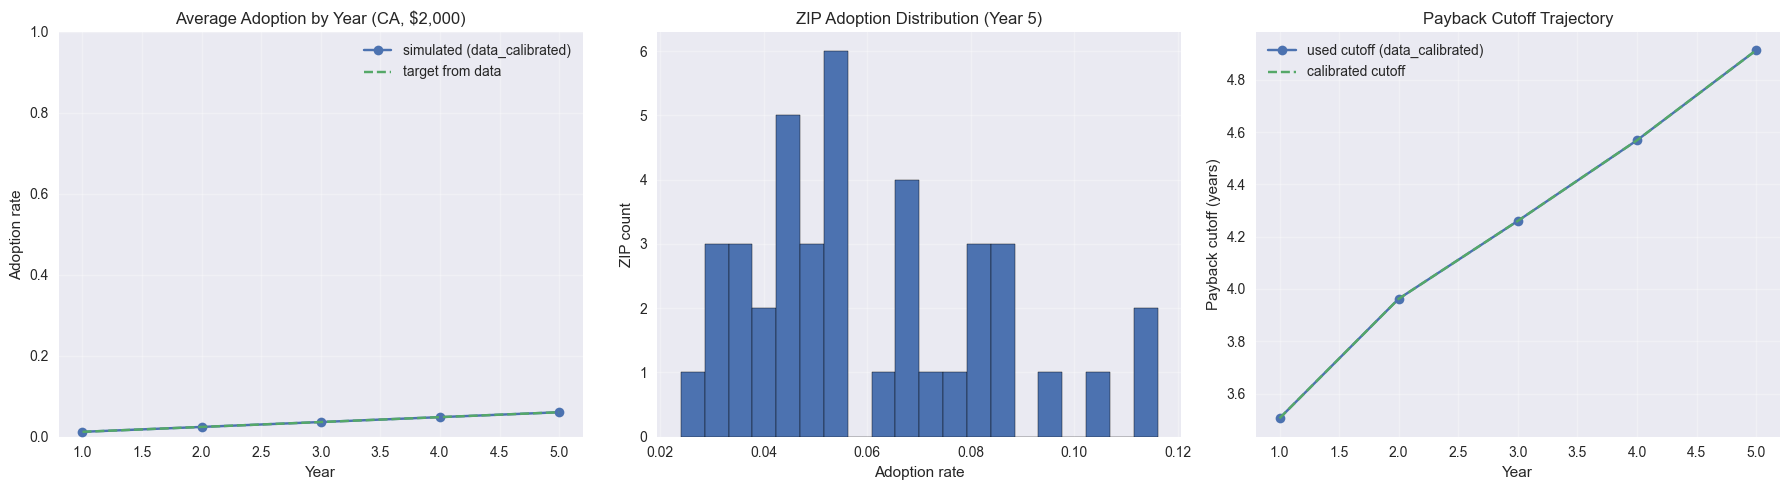

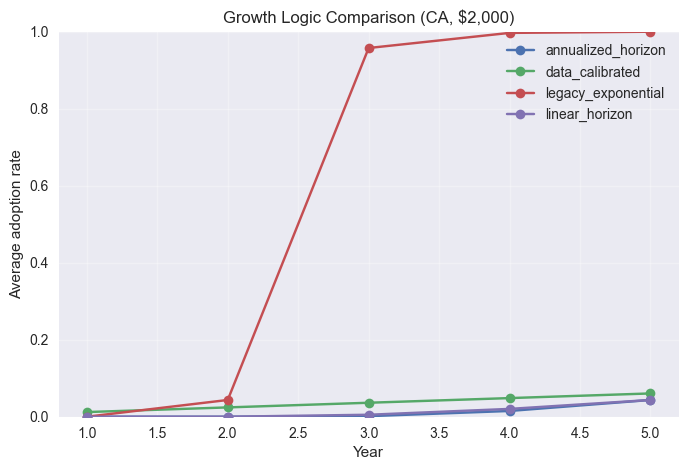

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: state average adoption over time for selected logic
axes[0].plot(summary_df["year"], summary_df["avg_adoption_rate"], marker="o", label=f"simulated ({GROWTH_LOGIC})")
if GROWTH_LOGIC == "data_calibrated":
    axes[0].plot(data_calibration_df["year"], data_calibration_df["target_adoption"], marker="x", linestyle="--", label="target from data")
axes[0].set_title(f"Average Adoption by Year ({STATE_CODE}, ${FEDERAL_INCENTIVE_DOLLARS:,})")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Adoption rate")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: ZIP-level distribution in final year for selected logic
final_col = f"adoption_rate_year_{YEARS_TO_SIMULATE}"
axes[1].hist(results_df[final_col], bins=20, edgecolor="black")
axes[1].set_title(f"ZIP Adoption Distribution (Year {YEARS_TO_SIMULATE})")
axes[1].set_xlabel("Adoption rate")
axes[1].set_ylabel("ZIP count")
axes[1].grid(True, alpha=0.3)

# Plot 3: payback cutoffs over time
axes[2].plot(diagnostics_summary_df["year"], diagnostics_summary_df["avg_payback_cutoff"], marker="o", label=f"used cutoff ({GROWTH_LOGIC})")
if GROWTH_LOGIC == "data_calibrated":
    axes[2].plot(data_calibration_df["year"], data_calibration_df["calibrated_cutoff"], marker="x", linestyle="--", label="calibrated cutoff")
axes[2].set_title("Payback Cutoff Trajectory")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Payback cutoff (years)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

if not compare_summary_df.empty:
    plt.figure(figsize=(8, 5))
    for logic, group in compare_summary_df.groupby("growth_logic"):
        plt.plot(group["year"], group["avg_adoption_rate"], marker="o", label=logic)

    plt.title(f"Growth Logic Comparison ({STATE_CODE}, ${FEDERAL_INCENTIVE_DOLLARS:,})")
    plt.xlabel("Year")
    plt.ylabel("Average adoption rate")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Optional: save outputs
# results_df.to_csv(repo_root / "Examples" / f"federal_incentive_{STATE_CODE}_{FEDERAL_INCENTIVE_DOLLARS}_{GROWTH_LOGIC}.csv", index=False)
# diagnostics_df.to_csv(repo_root / "Examples" / f"federal_incentive_debug_{STATE_CODE}_{FEDERAL_INCENTIVE_DOLLARS}_{GROWTH_LOGIC}.csv", index=False)
# data_calibration_df.to_csv(repo_root / "Examples" / f"data_calibration_{STATE_CODE}_{FEDERAL_INCENTIVE_DOLLARS}.csv", index=False)

## Federal Incentive Sweep (Data-Calibrated Cutoffs)

This section runs a nationwide simulation across federal incentive values and reports:
- Carbon Offset
- Energy Generation
- Racial Equity
- Income Equity
- Predicted panels built
- Total federal spending

Implementation detail: yearly payback cutoffs are calibrated once per state at a reference incentive (default `$0`) and then held fixed across incentive scenarios.

In [38]:
import sys
import time

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Data.data_load_util import make_dataset
from Simulation.projections_util import create_paper_objectives

# --- Federal sweep configuration ---
INCENTIVE_VALUES = list(range(-2000, 8001, 500))
REFERENCE_FEDERAL_INCENTIVE_FOR_CALIBRATION = 0
MAX_ZIPCODES_PER_STATE_FEDERAL = None  # set to e.g. 100 for faster debug runs

federal_model_cache_dir = repo_root / "Examples" / "model_cache" / "federal"
federal_model_cache_dir.mkdir(parents=True, exist_ok=True)


def build_state_cache_path(state_code, n_zips, installation_cost, solar_kw):
    return federal_model_cache_dir / (
        f"zip_payloads_{state_code}_n{n_zips}_cost{int(installation_cost)}_kw{solar_kw}.pkl"
    )


def build_state_payloads(state_code, installation_cost, solar_kw, zips_df_all, use_cache=True, force_rebuild=False):
    state_zipcodes = zips_df_all.loc[zips_df_all["state_code"] == state_code, "zip"].astype(int).tolist()
    if MAX_ZIPCODES_PER_STATE_FEDERAL:
        state_zipcodes = state_zipcodes[:MAX_ZIPCODES_PER_STATE_FEDERAL]

    cache_path = build_state_cache_path(state_code, len(state_zipcodes), installation_cost, solar_kw)

    if use_cache and cache_path.exists() and not force_rebuild:
        with open(cache_path, "rb") as f:
            cached = pickle.load(f)
        return cached["payloads"], cached.get("failed_zipcodes", [])

    payloads = []
    failed_zipcodes = []

    for zip_code in tqdm(state_zipcodes, desc=f"Build payloads {state_code}", unit="zip", leave=False):
        try:
            model = sd.SolarAdoptionModelZipCode(zip_code)
            model.set_installation_cost(installation_cost)
            model.set_solar_offset_per_home(solar_pv_sizing_kw=solar_kw)
            model.generate_agents()

            if len(model.schedule.agents) == 0:
                failed_zipcodes.append(zip_code)
                continue

            yearly_savings_coeff = []
            for agent in model.schedule.agents:
                burden = model.get_energy_burden_from_income(agent.income)
                ratio = model.get_energy_ratio_from_income(agent.income)
                yearly_savings_coeff.append(float(burden * agent.income * ratio))

            payloads.append(
                {
                    "zip": int(zip_code),
                    "num_agents": len(model.schedule.agents),
                    "installation_cost": float(installation_cost),
                    "yearly_savings_coeff": np.array(yearly_savings_coeff, dtype=float),
                }
            )
        except Exception:
            failed_zipcodes.append(zip_code)

    if use_cache:
        with open(cache_path, "wb") as f:
            pickle.dump({"payloads": payloads, "failed_zipcodes": failed_zipcodes}, f, protocol=pickle.HIGHEST_PROTOCOL)

    return payloads, failed_zipcodes


def required_incentives_from_payload(payload, cutoff):
    return payload["installation_cost"] - payload["yearly_savings_coeff"] * cutoff


def evaluate_cutoff_adoption_payloads(payloads, cutoff, incentive_threshold):
    zip_adoptions = []
    for payload in payloads:
        required = required_incentives_from_payload(payload, cutoff)
        zip_adoptions.append(float(np.mean(required <= incentive_threshold)))
    return float(np.mean(zip_adoptions)) if zip_adoptions else 0.0


def calibrate_state_cutoffs_from_data(payloads, target_curve, reference_federal_incentive):
    # model sign convention: subsidy +X dollars => threshold -X
    ref_threshold = -reference_federal_incentive
    return calibrate_data_based_cutoffs(
        payloads=payloads,
        yearly_targets=target_curve,
        incentive_threshold=ref_threshold,
    )


def adoption_at_final_year(payloads, cutoffs, federal_incentive):
    threshold = federal_incentive
    final_cutoff = cutoffs[-1]
    adoption_by_zip = {}
    for payload in payloads:
        required = required_incentives_from_payload(payload, final_cutoff)
        adoption_by_zip[payload["zip"]] = float(np.mean(required <= threshold))
    return adoption_by_zip


# Load national ZIP dataset used by objective metrics.
zips_metrics_df, _, _ = make_dataset(granularity="both", remove_outliers=False, load_dir_prefix=str(repo_root / "Data") + "/")
zip_lookup = zips_metrics_df.set_index("region_name")
objectives = create_paper_objectives()

states_to_run = sorted(state_behavior_df["State code"].tolist())
state_payloads = {}
state_cutoffs = {}
state_failed = {}

t0 = time.time()
for state_code in tqdm(states_to_run, desc="Prepare states", unit="state"):
    row = state_behavior_df[state_behavior_df["State code"] == state_code].iloc[0]
    target_curve = build_target_adoption_curve(
        float(row["prop_adopted_status_quo"][1:-1]),
        float(row["prop_adopted_per_year_average"]),
        YEARS_TO_SIMULATE,
        TARGET_ADOPTION_MODE,
    )

    install_cost = BASE_INSTALLATION_COST - float(row["Numeric state-level upfront incentive"])
    payloads, failed = build_state_payloads(
        state_code=state_code,
        installation_cost=install_cost,
        solar_kw=SOLAR_SYSTEM_KW,
        zips_df_all=zips_df,
        use_cache=USE_MODEL_CACHE,
        force_rebuild=FORCE_REBUILD_CACHE,
    )

    if len(payloads) == 0:
        state_failed[state_code] = failed
        continue

    cutoffs, _ = calibrate_state_cutoffs_from_data(
        payloads=payloads,
        target_curve=target_curve,
        reference_federal_incentive=REFERENCE_FEDERAL_INCENTIVE_FOR_CALIBRATION,
    )

    state_payloads[state_code] = payloads
    state_cutoffs[state_code] = cutoffs
    state_failed[state_code] = failed

print(f"Prepared {len(state_payloads)} states in {time.time()-t0:.1f}s")
print(f"States with no payloads: {len([s for s in states_to_run if s not in state_payloads])}")

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 221.61year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 102.97year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 120.03year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 89.97year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 59.27year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 139.28year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 238.66year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 60.01year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 72.00year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 80.03year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 204.14year/s]

Calibrating data-based cutoffs: 100%|██████████| 5/5 [00:00<00:00, 359.76year/s]

Prepare states: 100%|

Prepared 50 states in 16.3s
States with no payloads: 0


In [39]:
def adoption_at_year(payloads, cutoffs, federal_incentive, year_idx):
    threshold = federal_incentive
    year_cutoff = cutoffs[year_idx]
    adoption_by_zip = {}
    for payload in payloads:
        required = required_incentives_from_payload(payload, year_cutoff)
        adoption_by_zip[payload["zip"]] = float(np.mean(required <= threshold))
    return adoption_by_zip


federal_rows = []

for incentive in tqdm(INCENTIVE_VALUES, desc="Federal incentive sweep", unit="scenario"):
    for year_idx in range(YEARS_TO_SIMULATE):
        year_num = year_idx + 1
        placed_panels = {}

        for state_code, payloads in state_payloads.items():
            adoption_map = adoption_at_year(payloads, state_cutoffs[state_code], incentive, year_idx)

            for zip_code, adopt_rate in adoption_map.items():
                if zip_code not in zip_lookup.index:
                    continue
                qualified = float(zip_lookup.loc[zip_code, "count_qualified"])
                panels = max(0.0, adopt_rate * qualified)
                placed_panels[zip_code] = placed_panels.get(zip_code, 0.0) + panels

        total_panels = float(np.sum(list(placed_panels.values()))) if placed_panels else 0.0
        total_spending = float(incentive * total_panels)
        total_outlay = float(max(incentive, 0) * total_panels)

        metric_values = {}
        for obj in objectives:
            metric_values[obj.name] = float(obj.calc(zips_metrics_df, placed_panels))

        federal_rows.append(
            {
                "federal_incentive": incentive,
                "year": year_num,
                "total_panels_built": total_panels,
                "total_federal_spending": total_spending,
                "total_federal_outlay": total_outlay,
                "Carbon Offset": metric_values.get("Carbon Offset", np.nan),
                "Energy Generation": metric_values.get("Energy Potential", np.nan),
                "Racial Equity": metric_values.get("Racial Equity", np.nan),
                "Income Equity": metric_values.get("Income Equity", np.nan),
            }
        )

federal_results_df = pd.DataFrame(federal_rows).sort_values(["federal_incentive", "year"]).reset_index(drop=True)
display(federal_results_df.head())
display(federal_results_df.tail())

Federal incentive sweep: 100%|██████████| 21/21 [32:01<00:00, 91.51s/scenario] 


,federal_incentive,year,total_panels_built,total_federal_spending,total_federal_outlay,Carbon Offset,Energy Generation,Racial Equity,Income Equity
0,-2000,1,121292.125339,-2.425843e+08,0.0,17230.277346,1.467065e+08,1.412854,1.140460
1,-2000,2,244260.213741,-4.885204e+08,0.0,36068.439820,2.933999e+08,1.501839,1.297506
2,-2000,3,385839.972828,-7.716799e+08,0.0,57265.298760,4.643388e+08,1.544409,1.382914
3,-2000,4,565427.195492,-1.130854e+09,0.0,82749.584226,6.842744e+08,1.532810,1.399903
4,-2000,5,756175.138940,-1.512350e+09,0.0,109155.520496,9.195010e+08,1.505374,1.385379


,federal_incentive,year,total_panels_built,total_federal_spending,total_federal_outlay,Carbon Offset,Energy Generation,Racial Equity,Income Equity
100,8000,1,6.766564e+06,5.413252e+10,5.413252e+10,1.050112e+06,7.920866e+09,1.509591,1.336281
101,8000,2,1.072334e+07,8.578672e+10,8.578672e+10,1.618954e+06,1.260046e+10,1.531553,1.398493
102,8000,3,1.480766e+07,1.184613e+11,1.184613e+11,2.210918e+06,1.749548e+10,1.546081,1.476479
103,8000,4,1.897301e+07,1.517841e+11,1.517841e+11,2.829230e+06,2.240281e+10,1.583725,1.538934
104,8000,5,2.281766e+07,1.825413e+11,1.825413e+11,3.415763e+06,2.684452e+10,1.626015,1.591711


KeyError: 'year'

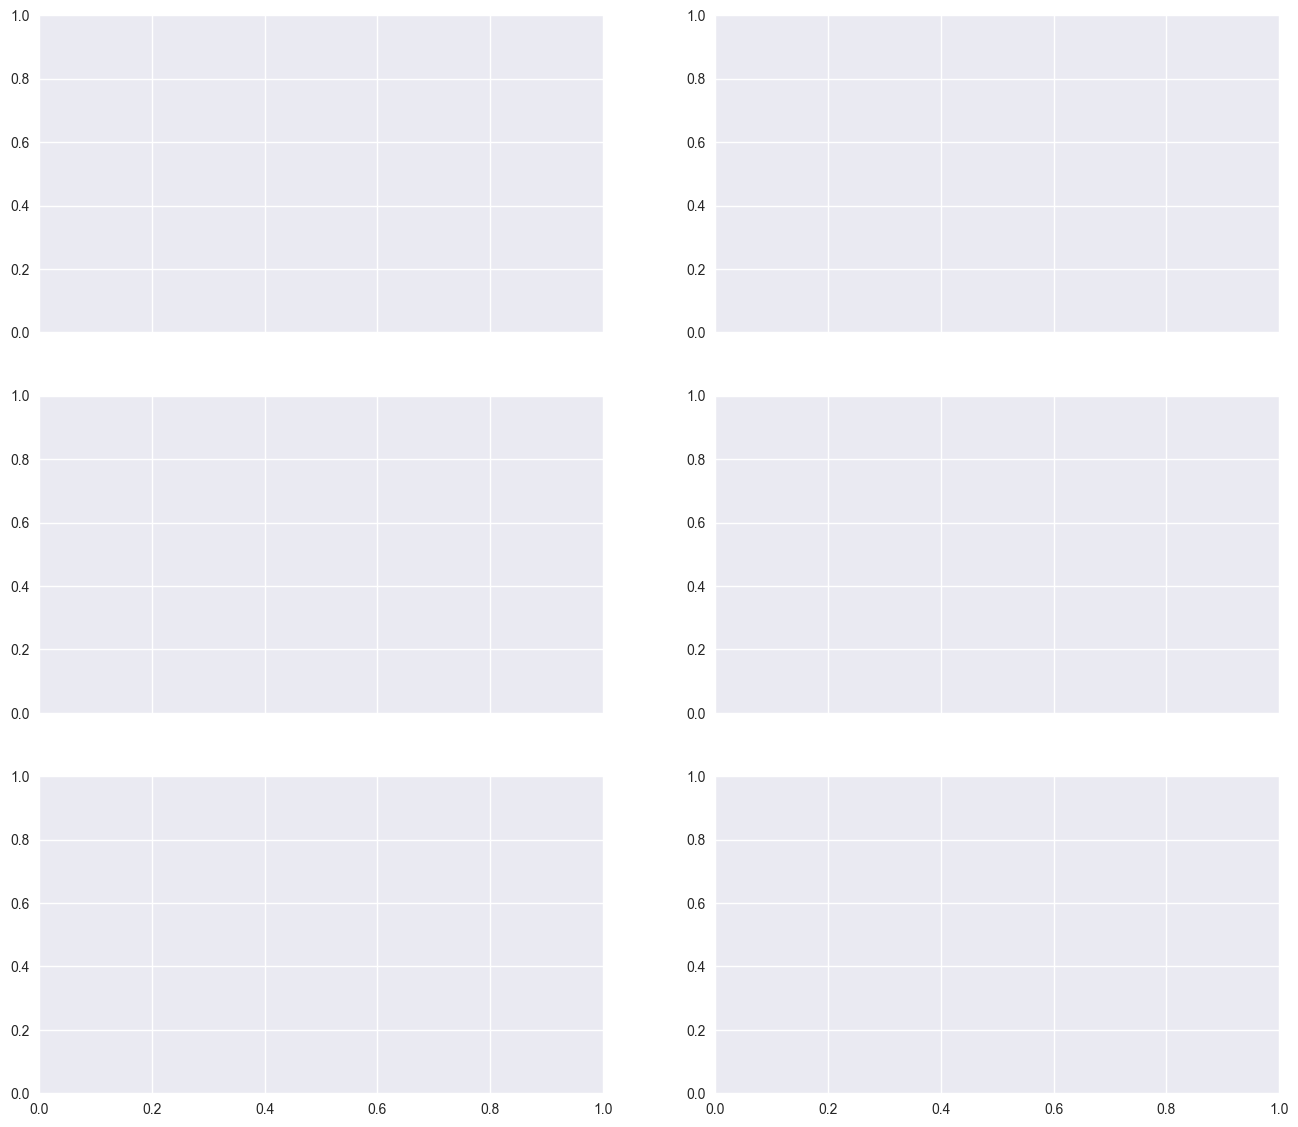

In [37]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

plot_specs = [
    ("Carbon Offset", "Carbon Offset", "Metric tons CO2 offset"),
    ("Energy Generation", "Energy Generation", "kWh potential"),
    ("Racial Equity", "Racial Equity", "Index"),
    ("Income Equity", "Income Equity", "Index"),
    ("total_panels_built", "Total Panels Built", "Panels"),
    ("total_federal_outlay", "Total Federal Outlay", "USD"),
]

incentives_sorted = sorted(federal_results_df["federal_incentive"].unique())
color_map = plt.get_cmap("viridis", len(incentives_sorted))

for ax, (col, title, y_label) in zip(axes, plot_specs):
    for idx, incentive in enumerate(incentives_sorted):
        sub = federal_results_df[federal_results_df["federal_incentive"] == incentive].sort_values("year")
        ax.plot(sub["year"], sub[col], marker="o", linewidth=1.5, color=color_map(idx), alpha=0.85)

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.3)

# Shared legend (one line per incentive)
legend_handles = [
    plt.Line2D([0], [0], color=color_map(i), lw=2, label=f"${inc}")
    for i, inc in enumerate(incentives_sorted)
]
fig.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.02, 0.5), title="Federal incentive")

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()

# Optional save
# federal_results_df.to_csv(repo_root / "Examples" / "federal_incentive_sweep_data_calibrated_by_year.csv", index=False)